In [1]:
#!pip install gymnasium[box2d]
#!pip install gym-notebook-wrapper
#!pip install huggingface_sb3 huggingface_hub
#!pip install pip install opencv-python

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/dexterneo/anaconda3/envs/GAME/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


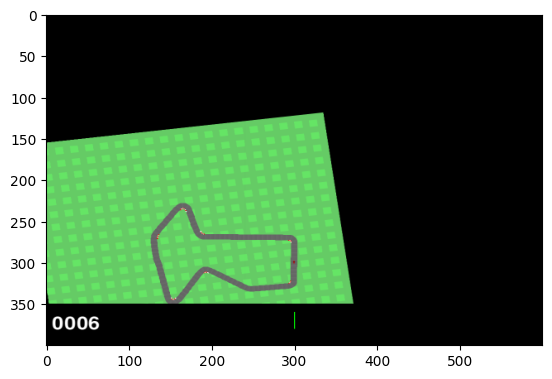

(400, 600, 3)


In [2]:
# Standard library imports
import math
import random
import os
import time

# Third-party imports
import cv2
import gnwrapper
import gym
import matplotlib.pyplot as plt
import numpy as np
import pygame
from pygame import gfxdraw
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint as ckpt_fn
from IPython.display import display, clear_output
from tqdm import tqdm
from PIL import Image

# Gym Box2D specific imports
from gym.envs.box2d.car_racing import CarRacing
from gym.envs.box2d.car_dynamics import Car  # We need this to spawn a second car
from game_envs.multicar_racing_orthographic import MultiCarOrthographicWrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CarRacingDiscrete(CarRacing):
    def __init__(self):
        # NEW: Explicitly set the render mode for Gym 0.26+
        super().__init__(render_mode="rgb_array")
        self.action_space = gym.spaces.Discrete(5)
        self.mapping = {
            0: [0.0, 0.0, 0.0],  # 0: noop
            1: [-1.0, 0.0, 0.0], # 1: left
            2: [1.0, 0.0, 0.0],  # 2: right
            3: [0.0, 1.0, 0.0],  # 3: gas
            4: [0.0, 0.0, 0.8],  # 4: brake
        }

    def step(self, action):
        if action is None:
            return super().step(None)
        return super().step(self.mapping[action])

# Initialize and wrap
env = CarRacingDiscrete()

obs, info = env.reset()
im = env.render()

# Plot the preprocessed image to verify
plt.imshow(im)
plt.show()
print(im.shape)

# Load Multi-Agent + Multi-View Environment

In [3]:
class MultiCarRacingContinuous(CarRacing):
    def __init__(self, difficulty=0.0):
        super().__init__(render_mode="rgb_array", continuous=True)
        self.opponent_car = None
        self.opponent_action = np.array([0.0, 0.0, 0.0])
        self.difficulty = np.clip(difficulty, 0.0, 1.0) # 0=Easy, 1=Nightmare

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        
        if self.car is not None:
            init_x, init_y = self.car.hull.position
            car_angle = self.car.hull.angle
            
            # --- SOCIAL ADVERSITY ---
            # d=0: 5.0 units apart | d=1: 2.5 units apart
            offset_dist = 5.0 - (self.difficulty * 2.5) 
            
            spawn_x = init_x + offset_dist * math.cos(car_angle)
            spawn_y = init_y + offset_dist * math.sin(car_angle)
            
            self.opponent_car = Car(self.world, car_angle, spawn_x, spawn_y+10)
            self.opponent_car.hull.color = (0.0, 0.0, 0.8) 
            self.opponent_action = np.array([0.0, 0.0, 0.0])

            # Let internal gym steps will draw the blue car into the state array!
            original_draw = self.car.draw
            def patched_draw(surf, zoom, translation, angle, draw_particles=True, **kwargs):
                original_draw(surf, zoom, translation, angle, draw_particles, **kwargs)
                if self.opponent_car is not None:
                    self.opponent_car.draw(surf, zoom, translation, angle, draw_particles=False, **kwargs)
                    
            self.car.draw = patched_draw            
            obs = self._render("state_pixels")
            
        return obs, info

    def get_opponent_obs(self):
        if self.opponent_car is None:
            return np.zeros((96, 96, 3), dtype=np.uint8)
        temp_car = self.car
        self.car = self.opponent_car
        obs = self._render("state_pixels")
        self.car = temp_car
        return obs

    def set_opponent_action(self, action):
        if isinstance(action, np.ndarray):
            self.opponent_action = action.flatten()

    def step(self, action):
        # 1. Step Opponent
        if self.opponent_car is not None:
            steer = float(self.opponent_action[0])
            gas = float(self.opponent_action[1])
            brake = float(self.opponent_action[2])
            self.opponent_car.steer(-steer)
            self.opponent_car.gas(gas)
            self.opponent_car.brake(brake)
            self.opponent_car.step(1.0 / 50.0) 
            
        # 2. Step Player & Physics World
        if action is not None:
            if isinstance(action, np.ndarray):
                action = action.flatten()
            clean_action = np.array([float(action[0]), float(action[1]), float(action[2])])
            return super().step(clean_action)
            
        return super().step(action)

    def render(self):
        if self.car is None:
            return super().render()
        original_draw = self.car.draw
        def patched_draw(surf, zoom, translation, angle, draw_particles=True, **kwargs):
            original_draw(surf, zoom, translation, angle, draw_particles, **kwargs)
            if self.opponent_car is not None:
                self.opponent_car.draw(surf, zoom, translation, angle, draw_particles=False, **kwargs)
        self.car.draw = patched_draw
        img = super().render()
        self.car.draw = original_draw 
        return img


Skipping frames while cars land...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 159.98it/s]


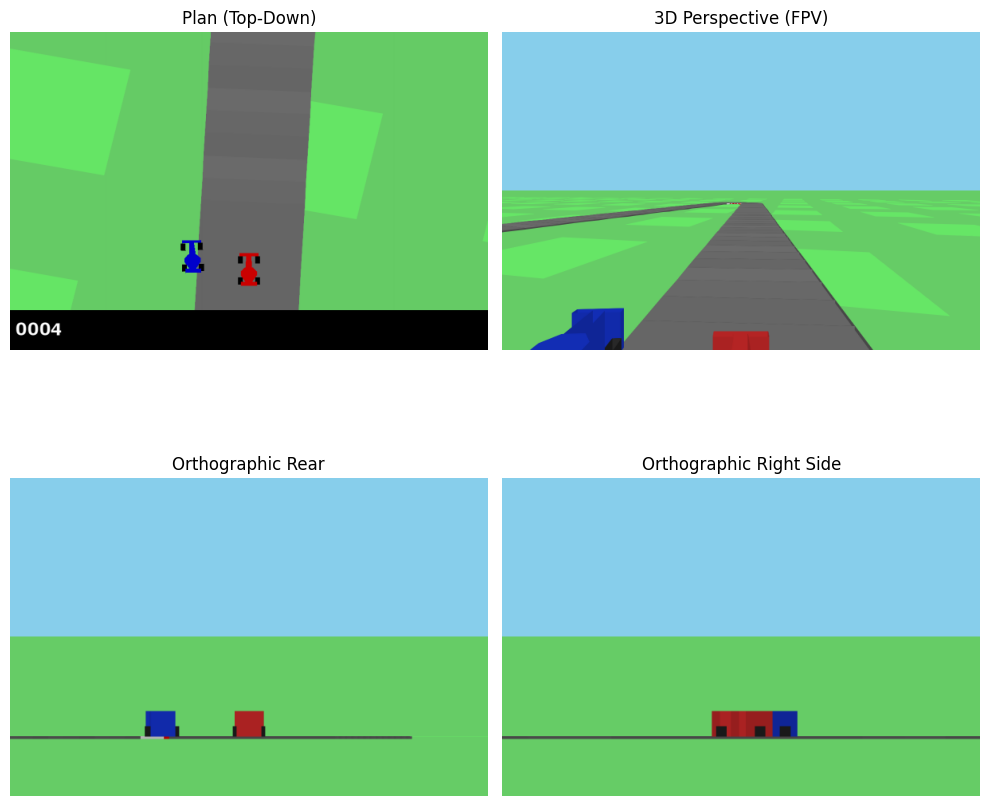

Top-Down Shape: (400, 600, 3)
Rear Shape: (400, 600, 3)
Side Shape: (400, 600, 3)
Perspective FPV Shape: (400, 600, 3)


In [4]:
base_env = MultiCarRacingContinuous(difficulty=1.0)
env = MultiCarOrthographicWrapper(base_env)
obs, info = env.reset()

print("Skipping frames while cars land...")
for _ in tqdm(range(50)):
    obs, reward, terminated, truncated, info = env.step([0.0, 0.0, 0.0])
    
# Unpack all 4 views
im_top_down, im_rear, im_side, im_fpv = env.render()

# Plot the 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(im_top_down)
axes[0, 0].set_title("Plan (Top-Down)")
axes[0, 0].axis('off')

axes[0, 1].imshow(im_fpv)
axes[0, 1].set_title("3D Perspective (FPV)")
axes[0, 1].axis('off')

axes[1, 0].imshow(im_rear)
axes[1, 0].set_title("Orthographic Rear")
axes[1, 0].axis('off')

axes[1, 1].imshow(im_side)
axes[1, 1].set_title("Orthographic Right Side")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Top-Down Shape: {im_top_down.shape}")
print(f"Rear Shape: {im_rear.shape}")
print(f"Side Shape: {im_side.shape}")
print(f"Perspective FPV Shape: {im_fpv.shape}")

In [5]:
from stable_baselines3 import PPO
from huggingface_sb3 import load_from_hub
from collections import deque

np.bool8 = np.bool_

# ===============================================================
# 1. DOWNLOAD WEIGHTS & DEFINE AGENT CLASS
# ===============================================================
print("Downloading solved PPO weights from Hugging Face...")
checkpoint = load_from_hub(
    repo_id="igpaub/ppo-CarRacing-v2",
    filename="ppo-CarRacing-v2.zip"
)

agent = PPO.load(checkpoint)

# ==========================================
# 2. ENVIRONMENT SETUP
# ==========================================
# Use the new Continuous environment
base_env = MultiCarRacingContinuous(difficulty=1) 
env = MultiCarOrthographicWrapper(base_env)

# ==========================================
# 3. INITIALIZATION & DATA EXTRACTION
# ==========================================
obs, info = env.reset()

print("Skipping intro animation...")
# Note: For continuous environments, 'noop' is an array of zeros
for _ in range(50):
    obs, _, _, _, _ = env.step(np.array([0.0, 0.0, 0.0]))

track_data = env.unwrapped.track
track_x = [tile[2] for tile in track_data]
track_y = [tile[3] for tile in track_data]

start_x = env.unwrapped.car.hull.position.x
start_y = env.unwrapped.car.hull.position.y

# ==========================================
# 4. LET THE AI DRIVE BOTH CARS
# ==========================================
total_reward = 0.0
print("Letting the AI control both cars...")

action_history_blue = deque(maxlen=5)
action_history_red = deque(maxlen=5)
image_list = []

num_frames = 200  # Adjust as needed
white_color = (255, 255, 255)

for step in range(num_frames):
    # --- BLUE CAR BRAIN ---
    obs_blue = env.unwrapped.get_opponent_obs()
    action_blue, _ = agent.predict(obs_blue, deterministic=True)
    env.unwrapped.set_opponent_action(action_blue)

    # --- RED CAR BRAIN ---
    action_red, _ = agent.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action_red)

    img, im_rear, im_side, im_first_person = env.render()

    # Track action history
    action_history_blue.append(action_blue)
    action_history_red.append(action_red)

    # ----------------------------------------------------
    # DUAL HUD ON SHARED FPV
    # ----------------------------------------------------
    fpv_hud = im_first_person.copy()
    h, w, _ = fpv_hud.shape
    half_w = w // 2
    
    white_color = (255, 255, 255)
    cyan_color = (0, 255, 255)
    red_color = (255, 0, 0)

    # --- Blue HUD (Left) ---
    overlay_blue = fpv_hud.copy()
    cv2.rectangle(overlay_blue, (10, 10), (min(210, half_w - 10), 130), (0, 0, 0), -1)
    fpv_hud = cv2.addWeighted(overlay_blue, 0.5, fpv_hud, 0.5, 0)

    cv2.putText(
        fpv_hud,
        "Blue Agent Action",
        (18, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        white_color,
        1,
        cv2.LINE_AA,
    )

    for i, act in enumerate(action_history_blue):
        is_current = i == len(action_history_blue) - 1
        prefix = "-> " if is_current else "   "
        act_str = f"{prefix}" + ", ".join(
            [f"{val:+.1f}" for val in np.atleast_1d(act)]
        )
        y_pos = 55 + (i * 15)
        
        # Apply Cyan color if it's the current action, otherwise White
        text_color = cyan_color if is_current else white_color
        
        cv2.putText(
            fpv_hud,
            act_str,
            (15, y_pos),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            text_color,
            1,
            cv2.LINE_AA,
        )

    # --- Red HUD (Right) ---
    red_box_x = half_w + 10
    overlay_red = fpv_hud.copy()
    cv2.rectangle(
        overlay_red,
        (red_box_x, 10),
        (min(red_box_x + 200, w - 10), 130),
        (0, 0, 0),
        -1,
    )
    fpv_hud = cv2.addWeighted(overlay_red, 0.5, fpv_hud, 0.5, 0)

    cv2.putText(
        fpv_hud,
        "Red Agent Action",
        (red_box_x + 8, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        white_color,
        1,
        cv2.LINE_AA,
    )

    for i, act in enumerate(action_history_red):
        is_current = i == len(action_history_red) - 1
        prefix = "-> " if is_current else "   "
        act_str = f"{prefix}" + ", ".join(
            [f"{val:+.1f}" for val in np.atleast_1d(act)]
        )
        y_pos = 55 + (i * 15)
        
        # Apply Red color if it's the current action, otherwise White
        text_color = red_color if is_current else white_color
        
        cv2.putText(
            fpv_hud,
            act_str,
            (red_box_x + 5, y_pos),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            text_color,
            1,
            cv2.LINE_AA,
        )

    car_x = env.unwrapped.car.hull.position.x
    car_y = env.unwrapped.car.hull.position.y
    car_angle = env.unwrapped.car.hull.angle

    blue_x = env.unwrapped.opponent_car.hull.position.x
    blue_y = env.unwrapped.opponent_car.hull.position.y
    blue_angle = env.unwrapped.opponent_car.hull.angle

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

      # [Row 0, Col 0] - Top-Down Camera
    axes[0, 0].imshow(img)
    axes[0, 0].set_title(f"Plan (Top-Down) - Step {step}")
    axes[0, 0].axis("off")

    # [Row 0, Col 1] - Shared 3D FPV with Side-by-Side HUDs
    axes[0, 1].imshow(fpv_hud)
    axes[0, 1].set_title("Shared 3D Perspective (FPV)")
    axes[0, 1].axis("off")

    # [Row 0, Col 2] - Minimap
    axes[0, 2].scatter(
          start_x,
          start_y,
          color="yellow",
          marker="*",
          s=300,
          edgecolors="black",
          zorder=3,
          label="Start",
    )
    axes[0, 2].plot(track_x, track_y, color="gray", linewidth=10, alpha=0.5)
    axes[0, 2].plot(track_x, track_y, color="black", linewidth=1, linestyle="--")

    axes[0, 2].scatter(
        car_x, car_y, color="red", s=100, zorder=5, label="Agent (Red)"
    )
    axes[0, 2].arrow(
        car_x,
          car_y,
          5.0 * -np.sin(car_angle),
          5.0 * np.cos(car_angle),
          color="red",
          width=2.0,
          zorder=5,
    )

    axes[0, 2].scatter(
        blue_x, blue_y, color="blue", s=100, zorder=5, label="Opponent (Blue)"
    )
    axes[0, 2].arrow(
          blue_x,
          blue_y,
          5.0 * -np.sin(blue_angle),
          5.0 * np.cos(blue_angle),
          color="blue",
          width=2.0,
          zorder=5,
      )

    act_r = action_red.flatten()
    act_b = action_blue.flatten()
    title_str = (
          f"Red  -> Steer: {act_r[0]:+.2f}   Gas: {act_r[1]:.2f}   Brake:"
          f" {act_r[2]:.2f}\n"
          f"Blue -> Steer: {act_b[0]:+.2f}   Gas: {act_b[1]:.2f}   Brake:"
          f" {act_b[2]:.2f}"
    )
    axes[0, 2].set_title(title_str)
    axes[0, 2].axis("equal")
    axes[0, 2].legend(loc="upper right")

    # [Row 1, Col 0] - Ortho Rear
    axes[1, 0].imshow(im_rear)
    axes[1, 0].set_title("Orthographic Rear")
    axes[1, 0].axis("off")

    # [Row 1, Col 1] - Ortho Side
    axes[1, 1].imshow(im_side)
    axes[1, 1].set_title("Orthographic Side")
    axes[1, 1].axis("off")

    # [Row 1, Col 2] - Blue Agent Observation Matrix
    axes[1, 2].imshow(obs_blue)
    axes[1, 2].set_title("Blue Car Internal Observation")
    axes[1, 2].axis("off")

    plt.tight_layout()

    # Capture canvas frame for GIF
    fig.canvas.draw()
    rgba_image = Image.frombytes(
          "RGBA", fig.canvas.get_width_height(), fig.canvas.buffer_rgba()
    )
    image_list.append(rgba_image.convert("RGB"))

    total_reward += reward

    # Live display inside notebook loop
    display(fig)
    clear_output(wait=True)
    plt.close(fig)

    if terminated or truncated:
        print(f"Episode finished at step {step}! Total Score: {total_reward:.2f}")
        break

# ==========================================
# 5. SAVE COLLECTED FRAMES TO A .GIF FILE
# ==========================================
gif_path = "multicar_dual_agent_run.gif"
print(f"Saving final animation to {gif_path}...")
image_list[0].save(
    gif_path,
    save_all=True,
    append_images=image_list[1:],
    duration=50,
    loop=0,
)
print(f"Saved successfully! Total Reward: {total_reward:.2f}")
env.close()

Saving final animation to multicar_dual_agent_run.gif...
Saved successfully! Total Reward: 172.86


# Train World Model

### Collect Rollouts in Buffer

In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
set_seed(42)

# ==========================================
# 1. SEQUENCE REPLAY BUFFER
# ==========================================
class TransitionSequenceBuffer:
    def __init__(self, capacity, img_h, img_w, max_track_len=400):
        self.capacity = capacity
        self.img_h = img_h
        self.img_w = img_w
        self.ptr = 0
        self.size = 0
        self.max_track_len = max_track_len
        
        # --- Images ---
        self.img_t = np.zeros((capacity, 3, img_h, img_w), dtype=np.uint8)
        self.im_first_person_t = np.zeros((capacity, 3, img_h, img_w), dtype=np.uint8)
        self.img_next = np.zeros((capacity, 3, img_h, img_w), dtype=np.uint8)
        self.im_first_person_next = np.zeros((capacity, 3, img_h, img_w), dtype=np.uint8)
        
        # --- Red Car (Ego) ---
        self.pose_t = np.zeros((capacity, 3), dtype=np.float32)
        self.pose_next = np.zeros((capacity, 3), dtype=np.float32)
        self.action_t = np.zeros((capacity, 3), dtype=np.float32)
        
        # --- Blue Car (Opponent) ---
        self.blue_pose_t = np.zeros((capacity, 3), dtype=np.float32)
        self.blue_pose_next = np.zeros((capacity, 3), dtype=np.float32)
        self.blue_action_t = np.zeros((capacity, 3), dtype=np.float32)
        
        # --- Environment ---
        self.done_t = np.zeros(capacity, dtype=bool)
        self.global_map_t = np.zeros((capacity, max_track_len, 2), dtype=np.float32) # PADDING FOR THE GLOBAL MAP
        self.track_mask_t = np.zeros((capacity, max_track_len), dtype=bool) # Mask the Global Map Padding
        
    def push(self, img, img_first_person, pose, action,
             global_map, track_mask,
             blue_pose, blue_action,
             next_img, next_first_person_img, next_pose, next_blue_pose, done):
        
        # Resize if image doesn't match buffer resolution
        h, w = img.shape[:2]
        if h != self.img_h or w != self.img_w:
            img = cv2.resize(img, (self.img_w, self.img_h), interpolation=cv2.INTER_AREA)
            next_img = cv2.resize(next_img, (self.img_w, self.img_h), interpolation=cv2.INTER_AREA)
            img_first_person = cv2.resize(img_first_person, (self.img_w, self.img_h), interpolation=cv2.INTER_AREA)
            next_first_person_img = cv2.resize(next_first_person_img, (self.img_w, self.img_h), interpolation=cv2.INTER_AREA)
        
        # Images
        self.img_t[self.ptr] = np.transpose(img, (2, 0, 1))
        self.im_first_person_t[self.ptr] = np.transpose(img_first_person, (2, 0, 1))
        self.img_next[self.ptr] = np.transpose(next_img, (2, 0, 1))
        self.im_first_person_next[self.ptr] = np.transpose(next_first_person_img, (2, 0, 1))
        
        # Red Car
        self.pose_t[self.ptr] = pose
        self.action_t[self.ptr] = action
        self.pose_next[self.ptr] = next_pose
        
        # Blue Car
        self.blue_pose_t[self.ptr] = blue_pose
        self.blue_action_t[self.ptr] = blue_action
        self.blue_pose_next[self.ptr] = next_blue_pose

        # Environment
        self.done_t[self.ptr] = done
        self.global_map_t[self.ptr] = global_map
        self.track_mask_t[self.ptr] = track_mask
        
        # Advance pointers
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
        
    def sample_sequence(self, batch_size, seq_len, device):
        """Samples a contiguous sequence of length seq_len."""
        idxs = np.zeros(batch_size, dtype=np.int32)
        
        # Ensure sequences don't cross episode boundaries OR the ring buffer pointer
        for i in range(batch_size):
            valid = False
            while not valid:
                idx = np.random.randint(0, self.size - seq_len)
                
                # 1. Prevent crossing the ring buffer wrap-around point
                if self.size == self.capacity and idx < self.ptr <= idx + seq_len:
                    continue
                    
                # 2. Prevent crossing episode boundaries (dones)
                if self.done_t[idx : idx + seq_len - 1].any():
                    continue
                    
                valid = True
                idxs[i] = idx
                
        # Slice sequences
        i_seq = np.stack([self.img_t[idx : idx + seq_len] for idx in idxs])
        i_first_seq = np.stack([self.im_first_person_t[idx : idx + seq_len] for idx in idxs])
        p_seq = np.stack([self.pose_t[idx : idx + seq_len] for idx in idxs])
        a_seq = np.stack([self.action_t[idx : idx + seq_len] for idx in idxs])

        g_map_seq = np.stack([self.global_map_t[idx : idx + seq_len] for idx in idxs])
        mask_seq = np.stack([self.track_mask_t[idx : idx + seq_len] for idx in idxs])
        
        b_p_seq = np.stack([self.blue_pose_t[idx : idx + seq_len] for idx in idxs])
        b_a_seq = np.stack([self.blue_action_t[idx : idx + seq_len] for idx in idxs])
        
        i_next_target = np.stack([self.img_next[idx + seq_len - 1] for idx in idxs])
        i_first_next_target = np.stack([self.im_first_person_next[idx + seq_len - 1] for idx in idxs])
        p_next_target = np.stack([self.pose_next[idx + seq_len - 1] for idx in idxs])
        b_p_next_target = np.stack([self.blue_pose_next[idx + seq_len - 1] for idx in idxs])
        
        # Convert to Tensors 
        i_seq_t = (torch.from_numpy(i_seq).to(device, non_blocking=True).float() / 127.5) - 1.0
        i_first_seq_t = (torch.from_numpy(i_first_seq).to(device, non_blocking=True).float() / 127.5) - 1.0
        i_next_t = (torch.from_numpy(i_next_target).to(device, non_blocking=True).float() / 127.5) - 1.0
        i_first_next_target_t = (torch.from_numpy(i_first_next_target).to(device, non_blocking=True).float() / 127.5) - 1.0
        
        p_seq_t = torch.from_numpy(p_seq).to(device, non_blocking=True)
        a_seq_t = torch.from_numpy(a_seq).to(device, non_blocking=True)
        p_next_t = torch.from_numpy(p_next_target).to(device, non_blocking=True)

        g_map_seq_t = torch.from_numpy(g_map_seq).to(device, non_blocking=True)
        mask_seq_t = torch.from_numpy(mask_seq).to(device, non_blocking=True)
        
        b_p_seq_t = torch.from_numpy(b_p_seq).to(device, non_blocking=True)
        b_a_seq_t = torch.from_numpy(b_a_seq).to(device, non_blocking=True)
        b_p_next_t = torch.from_numpy(b_p_next_target).to(device, non_blocking=True)
        
        delta_p = p_next_t - p_seq_t[:, -1]
        delta_b_p = b_p_next_t - b_p_seq_t[:, -1]
        
        return (i_seq_t, i_first_seq_t, p_seq_t, a_seq_t,
                g_map_seq_t, mask_seq_t,
                b_p_seq_t, b_a_seq_t,
                i_next_t, i_first_next_target_t, delta_p, delta_b_p)

def collect_rollouts(env, agent, buffer, n_steps, MAX_TRACK_LEN = 400):
    obs, _ = env.reset()
    for _ in range(50):
        obs, _, _, _, _ = env.step(np.array([0.0, 0.0, 0.0]))
        
    track_vertices = np.array([[t[2], t[3]] for t in env.unwrapped.track])

    track_vertices = np.array([[t[2], t[3]] for t in env.unwrapped.track])
    padded_track = np.zeros((MAX_TRACK_LEN, 2), dtype=np.float32)
    track_mask = np.zeros(MAX_TRACK_LEN, dtype=bool)
    t_len = min(len(track_vertices), MAX_TRACK_LEN)
    padded_track[:t_len] = track_vertices[:t_len]
    track_mask[:t_len] = True
    
    for _ in tqdm(range(n_steps)):

        # --- BLUE CAR BRAIN ---
        obs_blue = env.unwrapped.get_opponent_obs()
        action_blue, _ = agent.predict(obs_blue, deterministic=True)
        env.unwrapped.set_opponent_action(action_blue)
        blue_action_floats = [float(a) for a in action_blue]

        # --- RED CAR BRAIN ---
        action, _states = agent.predict(obs, deterministic=True)
        action_floats = [float(a) for a in action]
        
        img_t, im_rear_t, im_side_t, im_first_person_t = env.render()
        
        # --- RED CAR POSITION (t) ---
        car_x, car_y = env.unwrapped.car.hull.position
        car_angle = env.unwrapped.car.hull.angle
        pose_t = np.array([car_x, car_y, car_angle], dtype=np.float32)

        # --- BLUE CAR POSITION (t) ---
        blue_x = env.unwrapped.opponent_car.hull.position.x
        blue_y = env.unwrapped.opponent_car.hull.position.y
        blue_angle = env.unwrapped.opponent_car.hull.angle
        blue_pose_t = np.array([blue_x, blue_y, blue_angle], dtype=np.float32)
        
        # ==========================================
        # STEP ENVIRONMENT
        # ==========================================
        next_obs, reward, terminated, truncated, _ = env.step(action_floats)
        done = terminated or truncated
        
        img_next, im_rear_next, im_side_next, im_first_person_next = env.render()
        
        # --- RED CAR POSITION (t+1) ---
        next_x, next_y = env.unwrapped.car.hull.position
        next_angle = env.unwrapped.car.hull.angle
        pose_next = np.array([next_x, next_y, next_angle], dtype=np.float32)
        
        # --- BLUE CAR POSITION (t+1) ---
        next_blue_x = env.unwrapped.opponent_car.hull.position.x
        next_blue_y = env.unwrapped.opponent_car.hull.position.y
        next_blue_angle = env.unwrapped.opponent_car.hull.angle
        next_blue_pose = np.array([next_blue_x, next_blue_y, next_blue_angle], dtype=np.float32)
        
        # --- PUSH TO BUFFER ---
        buffer.push(
            img_t, 
            im_first_person_t, 
            pose_t, 
            np.array(action_floats, dtype=np.float32), 
            padded_track,
            track_mask,
            blue_pose_t, 
            np.array(blue_action_floats, dtype=np.float32),
            img_next, 
            im_first_person_next, 
            pose_next, 
            next_blue_pose, 
            done
        )
        
        obs = next_obs
        
        if done:
            obs, _ = env.reset()
            for _ in range(50): 
                obs, _, _, _, _ = env.step([0.0, 0.0, 0.0])

            track_vertices = np.array([[t[2], t[3]] for t in env.unwrapped.track])
            padded_track = np.zeros((MAX_TRACK_LEN, 2), dtype=np.float32)
            track_mask = np.zeros(MAX_TRACK_LEN, dtype=bool)
            t_len = min(len(track_vertices), MAX_TRACK_LEN)
            padded_track[:t_len] = track_vertices[:t_len]
            track_mask[:t_len] = True
            
    env.close()

base_env = MultiCarRacingContinuous(difficulty=1.0)
env = MultiCarOrthographicWrapper(base_env)

buffer = TransitionSequenceBuffer(capacity=5000, img_h=64, img_w=64)
WARMUP_STEPS = 100
print(f"Warming up buffers: Collecting {WARMUP_STEPS} initial transitions per GPU...")
collect_rollouts(env, agent, buffer, n_steps=WARMUP_STEPS)

Warming up buffers: Collecting 100 initial transitions per GPU...


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.29it/s]


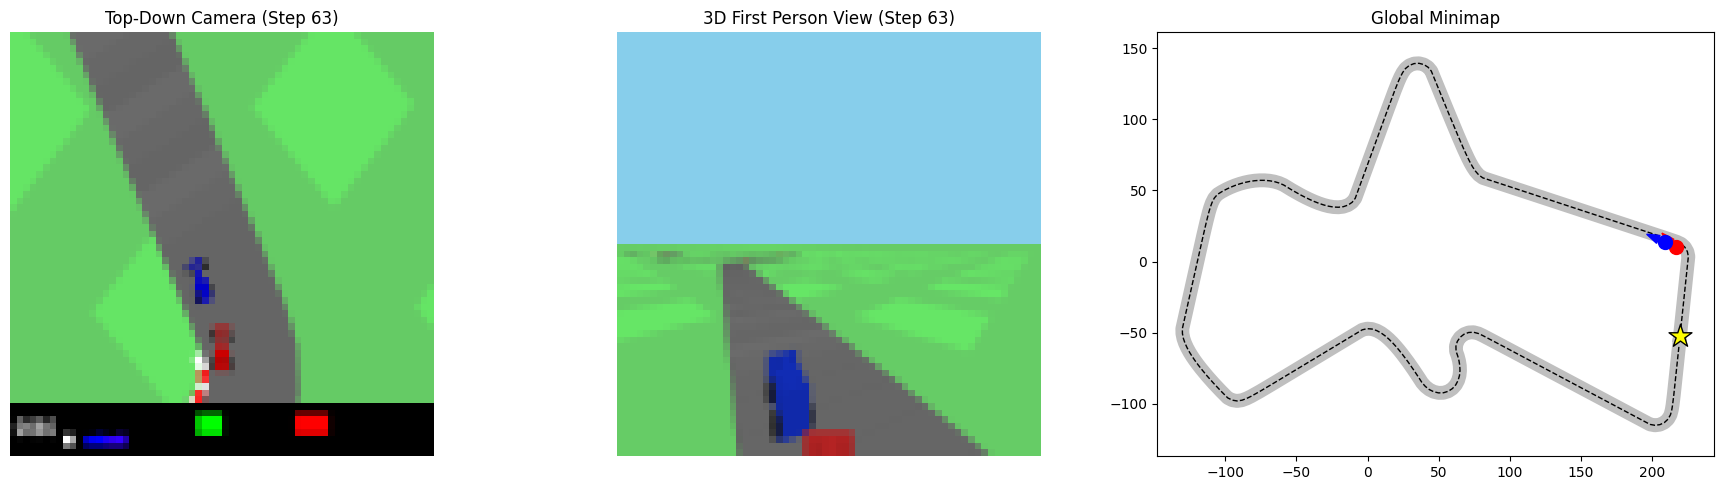

In [7]:
from IPython.display import clear_output

# 1. Sample the sequence
(img_seq, img_pov_seq, pose_seq, act_seq, 
 g_map_seq, mask_seq, 
 b_seq, b_action_seq, 
 next_img_target, next_pov_target, 
 target_delta, target_delta_b) = buffer.sample_sequence(batch_size=1, seq_len=64, device=device)

# 2. Extract arrays to CPU
p_seq_np = pose_seq.squeeze(0).cpu().numpy()       # Shape: (8, 3)
b_seq_np = b_seq.squeeze(0).cpu().numpy()          # Shape: (8, 3)
a_seq_np = act_seq.squeeze(0).cpu().numpy()        # Shape: (8, 3)
b_act_seq_np = b_action_seq.squeeze(0).cpu().numpy() # Shape: (8, 3)

# Extract global track and mask from the first step
global_track_padded = g_map_seq.squeeze(0)[0].cpu().numpy()
track_mask = mask_seq.squeeze(0)[0].cpu().numpy()
global_track = global_track_padded[track_mask]

# Define track coordinates
if len(global_track) > 0:
    track_x = global_track[:, 0]
    track_y = global_track[:, 1]
    start_x, start_y = track_x[0], track_y[0]
else:
    track_x, track_y, start_x, start_y = [], [], 0, 0

seq_len = p_seq_np.shape[0]

# 3. Animate the sequence
for t in range(seq_len):
    clear_output(wait=True)
    
    # Setup the 3-panel layout
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # ==========================================
    # AX1: TOP-DOWN CAMERA
    # ==========================================
    img_np = img_seq.squeeze(0)[t].detach().cpu().numpy()
    img_np = np.transpose(img_np, (1, 2, 0))
    img_np = ((img_np + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)

    ax1.imshow(img_np)
    ax1.set_title(f"Top-Down Camera (Step {t})")
    ax1.axis('off')

    # ==========================================
    # AX2: 3D FIRST PERSON VIEW
    # ==========================================
    pov_np = img_pov_seq.squeeze(0)[t].detach().cpu().numpy()
    pov_np = np.transpose(pov_np, (1, 2, 0))
    pov_np = ((pov_np + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)

    ax2.imshow(pov_np)
    ax2.set_title(f"3D First Person View (Step {t})")
    ax2.axis('off')

    # ==========================================
    # AX3: MINIMAP
    # ==========================================
    ax3.set_title("Global Minimap")
    if len(track_x) > 0:
        ax3.scatter(start_x, start_y, color='yellow', marker='*', s=300, edgecolors='black', zorder=3, label="Start")
        # Draw track following your styling
        ax3.plot(track_x, track_y, color='gray', linewidth=10, alpha=0.5)
        ax3.plot(track_x, track_y, color='black', linewidth=1, linestyle='--')

    # Extract poses for step t
    car_x, car_y, car_angle = p_seq_np[t]
    blue_x, blue_y, blue_angle = b_seq_np[t]

    # Draw Agent (Red)
    ax3.scatter(car_x, car_y, color='red', s=100, zorder=5, label='Agent (Red)')
    ax3.arrow(car_x, car_y, 5.0*-np.sin(car_angle), 5.0*np.cos(car_angle), color='red', width=2.0, zorder=5)

    # Draw Opponent (Blue)
    ax3.scatter(blue_x, blue_y, color='blue', s=100, zorder=5, label='Opponent (Blue)')
    ax3.arrow(blue_x, blue_y, 5.0*-np.sin(blue_angle), 5.0*np.cos(blue_angle), color='blue', width=2.0, zorder=5)

    ax3.set_aspect('equal', adjustable='datalim')
    if t == 0:
        ax3.legend(loc='best')
        
    plt.tight_layout()
    plt.show()

# Declare World Model

In [8]:
# ==========================================
# 2. COSINE NOISE SCHEDULE
# ==========================================
def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine schedule as proposed in Nichol & Dhariwal 2021."""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.999)
    
# ==========================================
# 3. DIFFUSION U-NET WITH ATTENTION & GRU WORLD MODEL
# ==========================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResBlock(nn.Module):
    """Residual block with GroupNorm and SiLU."""
    def __init__(self, in_ch, out_ch, emb_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.emb_proj(emb).unsqueeze(-1).unsqueeze(-1)
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)

class SelfAttention(nn.Module):
    """Self-attention layer for spatial feature maps."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        b, c, h, w = x.shape
        x_flat = self.norm(x).view(b, c, h * w).permute(0, 2, 1)  # (B, HW, C)
        attn_out, _ = self.attn(x_flat, x_flat, x_flat)
        return x + attn_out.permute(0, 2, 1).view(b, c, h, w)

class MapEncoder(nn.Module):
    """A lightweight PointNet to encode the padded global track vertices into a fixed-size vector."""
    def __init__(self, out_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, track_pts, mask):
        # Apply MLP to every point independently
        x = self.mlp(track_pts)  
        
        # Mask out the zero-padded points by setting them to a huge negative number 
        x = x.masked_fill(~mask.unsqueeze(-1), -1e9)
        
        # Global Max Pooling over the 400 points
        x_max, _ = x.max(dim=1) 
        return x_max


class ConditionalUNet(nn.Module):
    def __init__(self, cond_dim=256, base_ch=32, in_channels=6, out_channels=3):
        super().__init__()
        ch1, ch2, ch3, ch4, ch5 = base_ch, base_ch*2, base_ch*4, base_ch*8, base_ch*16
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(64),
            nn.Linear(64, 256), nn.GELU(),
            nn.Linear(256, 256)
        )
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, 256), nn.GELU(),
            nn.Linear(256, 256)
        )
        self.noise_aug_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(64),
            nn.Linear(64, 256), nn.GELU(),
            nn.Linear(256, 256)
        )
        
        # UPDATED: Use in_channels (12)
        self.inc = ResBlock(in_channels, ch1, emb_dim=256)
        
        self.down1 = nn.MaxPool2d(2)
        self.res_down1 = ResBlock(ch1, ch2, emb_dim=256)
        self.down2 = nn.MaxPool2d(2)
        self.res_down2 = ResBlock(ch2, ch3, emb_dim=256)
        self.down3 = nn.MaxPool2d(2)
        self.res_down3 = ResBlock(ch3, ch4, emb_dim=256)
        self.attn_down3 = SelfAttention(ch4)
        self.down4 = nn.MaxPool2d(2)
        self.res_down4 = ResBlock(ch4, ch5, emb_dim=256)
        
        self.bot1 = ResBlock(ch5, ch5, emb_dim=256)
        self.bot2 = ResBlock(ch5, ch5, emb_dim=256)
        
        self.res_up1 = ResBlock(ch5 + ch4, ch4, emb_dim=256)
        self.attn_up1 = SelfAttention(ch4)
        self.res_up2 = ResBlock(ch4 + ch3, ch3, emb_dim=256)
        self.res_up3 = ResBlock(ch3 + ch2, ch2, emb_dim=256)
        self.res_up4 = ResBlock(ch2 + ch1, ch1, emb_dim=256)
        
        # UPDATED: Use out_channels (6)
        self.outc = nn.Conv2d(ch1, out_channels, kernel_size=3, padding=1)

    def _encoder_block(self, x, emb):
        x1 = self.inc(x, emb)
        x2 = self.res_down1(self.down1(x1), emb)
        x3 = self.res_down2(self.down2(x2), emb)
        x4 = self.attn_down3(self.res_down3(self.down3(x3), emb))
        x5 = self.res_down4(self.down4(x4), emb)
        return x1, x2, x3, x4, x5
    
    def _decoder_block(self, x5, x4, x3, x2, x1, emb):
        x5 = self.bot1(x5, emb)
        x5 = self.bot2(x5, emb)
        up5 = F.interpolate(x5, size=x4.shape[2:], mode='nearest')
        x = self.attn_up1(self.res_up1(torch.cat([up5, x4], dim=1), emb))
        up4 = F.interpolate(x, size=x3.shape[2:], mode='nearest')
        x = self.res_up2(torch.cat([up4, x3], dim=1), emb)
        up3 = F.interpolate(x, size=x2.shape[2:], mode='nearest')
        x = self.res_up3(torch.cat([up3, x2], dim=1), emb)
        up2 = F.interpolate(x, size=x1.shape[2:], mode='nearest')
        x = self.res_up4(torch.cat([up2, x1], dim=1), emb)
        return self.outc(x)

    def forward(self, x_noisy, t, x_cond, h_t, noise_aug_level=None):
        emb = self.time_mlp(t) + self.cond_mlp(h_t)
        
        if noise_aug_level is not None:
            emb = emb + self.noise_aug_mlp(noise_aug_level.float())
        
        x = torch.cat([x_noisy, x_cond], dim=1)
        
        if self.training:
            x1, x2, x3, x4, x5 = ckpt_fn(self._encoder_block, x, emb, use_reentrant=False)
            return ckpt_fn(self._decoder_block, x5, x4, x3, x2, x1, emb, use_reentrant=False)
        else:
            x1, x2, x3, x4, x5 = self._encoder_block(x, emb)
            return self._decoder_block(x5, x4, x3, x2, x1, emb)

class RecurrentDiffusionWorldModel(nn.Module):
    def __init__(self, timesteps=200, hidden_dim=256, noise_aug_max=20, cond_drop_prob=0.1, base_ch=32):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.noise_aug_max = noise_aug_max
        self.cond_drop_prob = cond_drop_prob
        
        self.unet = ConditionalUNet(cond_dim=hidden_dim, base_ch=base_ch, in_channels=6, out_channels=3)
        
        # Keep the vision encoder at 6 channels for the RNN state
        enc_dim = 128
        self.encoder = nn.Sequential(
            nn.Conv2d(6, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, enc_dim, 4, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()
        )
        
        map_feat_dim = 64
        self.map_encoder = MapEncoder(out_dim=map_feat_dim)
        
        gru_input_dim = enc_dim + 3 + 3 + 3 + 3 + map_feat_dim
        self.gru = nn.GRUCell(gru_input_dim, hidden_dim)
        
        self.red_pose_head = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Linear(128, 3))
        self.blue_pose_head = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Linear(128, 3))
        
        self.timesteps = timesteps
        betas = cosine_beta_schedule(timesteps)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('alphas_cumprod_prev', alphas_cumprod_prev)
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1. - alphas_cumprod))
        self.register_buffer('posterior_variance', betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod))

    def forward(self, img_seq, pov_seq, pose_seq, act_seq, b_pose_seq, b_act_seq, g_map_seq, mask_seq, img_next_target=None, pov_next_target=None):
        b, seq_len, _, _, _ = img_seq.shape
        device = img_seq.device
        
        h = torch.zeros(b, self.hidden_dim, device=device)
        map_feats = self.map_encoder(g_map_seq[:, 0], mask_seq[:, 0]) 
        
        combined_img_seq = torch.cat([img_seq, pov_seq], dim=2)
        
        for t in range(seq_len):
            z_t = self.encoder(combined_img_seq[:, t])
            vec_in = torch.cat([
                z_t, pose_seq[:, t] / 100.0, act_seq[:, t], 
                b_pose_seq[:, t] / 100.0, b_act_seq[:, t], map_feats / 50.0   
            ], dim=1)
            h = self.gru(vec_in, h)
            
        pred_red_delta = self.red_pose_head(h)
        pred_blue_delta = self.blue_pose_head(h)
        
        if img_next_target is not None and pov_next_target is not None:
            t_diff = torch.randint(0, self.timesteps, (b,), device=device).long()
            
            # 1. Add noise to both images independently
            noise_img = torch.randn_like(img_next_target)
            noise_pov = torch.randn_like(pov_next_target)
            
            sqrt_alpha_t = self.sqrt_alphas_cumprod[t_diff].view(-1, 1, 1, 1)
            sqrt_one_minus_alpha_t = self.sqrt_one_minus_alphas_cumprod[t_diff].view(-1, 1, 1, 1)
            
            noisy_img = sqrt_alpha_t * img_next_target + sqrt_one_minus_alpha_t * noise_img
            noisy_pov = sqrt_alpha_t * pov_next_target + sqrt_one_minus_alpha_t * noise_pov
            
            # 2. Process conditions and noise augmentations
            cond_img = img_seq[:, -1]
            cond_pov = pov_seq[:, -1]
            noise_aug_level = torch.zeros(b, device=device, dtype=torch.long)
            h_unet = h.clone()
            
            if self.training:
                noise_aug_level = torch.randint(0, self.noise_aug_max, (b,), device=device).long()
                
                # Apply augmentation independently
                aug_n_img = torch.randn_like(cond_img)
                aug_n_pov = torch.randn_like(cond_pov)
                sq_a_aug = self.sqrt_alphas_cumprod[noise_aug_level].view(-1, 1, 1, 1)
                sq_one_m_aug = self.sqrt_one_minus_alphas_cumprod[noise_aug_level].view(-1, 1, 1, 1)
                
                cond_img = sq_a_aug * cond_img + sq_one_m_aug * aug_n_img
                cond_pov = sq_a_aug * cond_pov + sq_one_m_aug * aug_n_pov
                
                drop_mask = torch.rand(b, device=device) < self.cond_drop_prob
                if drop_mask.any():
                    h_unet[drop_mask] = 0.0
                    cond_img[drop_mask] = 0.0
                    cond_pov[drop_mask] = 0.0
            
            # 3. BATCH MULTIPLEXING: Stack along dim=0 (Batch dimension)
            # Shapes go from (B, 3, H, W) to (2B, 3, H, W)
            noisy_stacked = torch.cat([noisy_img, noisy_pov], dim=0)
            cond_stacked = torch.cat([cond_img, cond_pov], dim=0)
            
            # Duplicate the 1D/2D conditions to match the 2B batch size
            t_stacked = torch.cat([t_diff, t_diff], dim=0)
            h_stacked = torch.cat([h_unet, h_unet], dim=0)
            noise_aug_stacked = torch.cat([noise_aug_level, noise_aug_level], dim=0)
            
            # 4. Single Forward Pass
            pred_noise_stacked = self.unet(noisy_stacked, t_stacked, cond_stacked, h_stacked, noise_aug_level=noise_aug_stacked)
            
            # 5. SPLIT back into separate tensors
            pred_noise_img, pred_noise_pov = torch.split(pred_noise_stacked, b, dim=0)
            
            return pred_noise_img, pred_noise_pov, noise_img, noise_pov, pred_red_delta, pred_blue_delta
        
        return pred_red_delta, pred_blue_delta
        
    @torch.no_grad()
    def sample(self, img_seq, pov_seq, pose_seq, act_seq, b_pose_seq, b_act_seq, g_map_seq, mask_seq):
        """Runs the diffusion sampling loop using batch multiplexing."""
        self.eval() 
        b, seq_len, _, h_img, w_img = img_seq.shape
        device = img_seq.device
        
        h = torch.zeros(b, self.hidden_dim, device=device)
        map_feats = self.map_encoder(g_map_seq[:, 0], mask_seq[:, 0]) 
        combined_img_seq = torch.cat([img_seq, pov_seq], dim=2)
        
        for t in range(seq_len):
            z_t = self.encoder(combined_img_seq[:, t])
            vec_in = torch.cat([
                z_t, pose_seq[:, t]/100.0, act_seq[:, t], 
                b_pose_seq[:, t]/100.0, b_act_seq[:, t], map_feats/50.0
            ], dim=1)
            h = self.gru(vec_in, h)
            
        pred_red_delta = self.red_pose_head(h)
        pred_blue_delta = self.blue_pose_head(h)
        
        # Start with separate noise tensors
        x_t_img = torch.randn((b, 3, h_img, w_img), device=device)
        x_t_pov = torch.randn((b, 3, h_img, w_img), device=device)
        
        # Stack conditions
        cond_stacked = torch.cat([img_seq[:, -1], pov_seq[:, -1]], dim=0)
        h_stacked = torch.cat([h, h], dim=0)
        
        for i in reversed(range(self.timesteps)):
            t_tensor = torch.full((b,), i, device=device, dtype=torch.long)
            t_stacked = torch.cat([t_tensor, t_tensor], dim=0)
            
            # Stack the noisy images
            x_t_stacked = torch.cat([x_t_img, x_t_pov], dim=0)
            
            pred_noise_stacked = self.unet(x_noisy=x_t_stacked, t=t_stacked, x_cond=cond_stacked, h_t=h_stacked)
            
            # Split back for DDPM math
            pred_noise_img, pred_noise_pov = torch.split(pred_noise_stacked, b, dim=0)
            
            alpha_t = self.alphas[i]
            alpha_cumprod_t = self.alphas_cumprod[i]
            beta_t = self.betas[i]
            
            if i > 0:
                noise_img = torch.randn_like(x_t_img)
                noise_pov = torch.randn_like(x_t_pov)
            else:
                noise_img = torch.zeros_like(x_t_img)
                noise_pov = torch.zeros_like(x_t_pov)
                
            x_t_img = (1 / torch.sqrt(alpha_t)) * (x_t_img - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * pred_noise_img) + torch.sqrt(beta_t) * noise_img
            x_t_pov = (1 / torch.sqrt(alpha_t)) * (x_t_pov - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * pred_noise_pov) + torch.sqrt(beta_t) * noise_pov
            
        pred_img = torch.clamp(x_t_img, -1.0, 1.0)
        pred_pov = torch.clamp(x_t_pov, -1.0, 1.0)
        
        self.train() 
        return pred_img, pred_pov, pred_red_delta, pred_blue_delta

In [9]:
model = RecurrentDiffusionWorldModel(
    timesteps=200,
    hidden_dim=128,
    noise_aug_max=20,
    cond_drop_prob=0.1,
    base_ch=32
).to(device)
print(model)

RecurrentDiffusionWorldModel(
  (unet): ConditionalUNet(
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (cond_mlp): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
    (noise_aug_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (inc): ResBlock(
      (conv1): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm

In [10]:
(i_seq, i_first_seq, p_seq, a_seq, 
 g_map_seq, mask_seq, 
 b_p_seq, b_a_seq, 
 i_next, i_first_next, 
 delta_p, delta_b_p) = buffer.sample_sequence(1, 8, device)

# 2. Forward Pass
(pred_noise_img, pred_noise_pov, 
 target_noise_img, target_noise_pov, 
 pred_red_delta, pred_blue_delta) = model(
    img_seq=i_seq, 
    pov_seq=i_first_seq,
    pose_seq=p_seq, 
    act_seq=a_seq, 
    b_pose_seq=b_p_seq, 
    b_act_seq=b_a_seq, 
    g_map_seq=g_map_seq, 
    mask_seq=mask_seq, 
    img_next_target=i_next, 
    pov_next_target=i_first_next
)

# Generate the model's prediction
print("Running diffusion sampling loop (this takes a moment)...")

pred_img, pred_pov, pred_red_delta, pred_blue_delta = model.sample(
    i_seq, i_first_seq, p_seq, a_seq, b_p_seq, b_a_seq, g_map_seq, mask_seq
)

Running diffusion sampling loop (this takes a moment)...


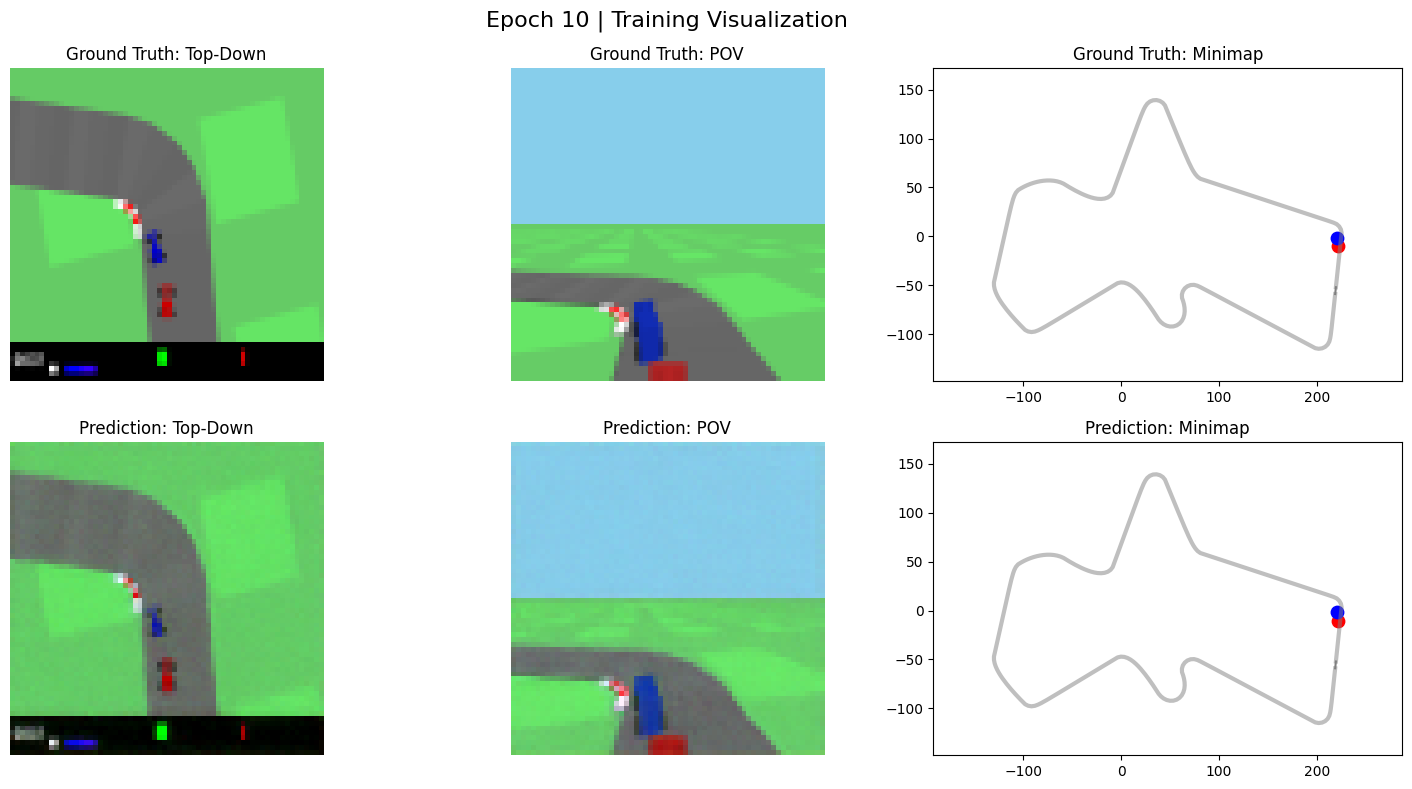

Training Complete!
Saving training animation to training_progression.gif...
Saved successfully as 'training_progression.gif'!


In [14]:
import torch.optim as optim
from tqdm import tqdm
from IPython.display import clear_output, display

# --- HELPER: VISUALIZATION DASHBOARD ---
def tensor_to_img(tensor):
    img = tensor.squeeze(0).detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    return ((img + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)

def visualize_training_step(epoch, gt_td, gt_pov, pred_td, pred_pov, gt_red, gt_blue, pred_red, pred_blue, track, image_list, save=True):
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Epoch {epoch} | Training Visualization", fontsize=16)

    # --- ROW 1: GROUND TRUTH ---
    axes[0, 0].imshow(tensor_to_img(gt_td))
    axes[0, 0].set_title("Ground Truth: Top-Down")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(tensor_to_img(gt_pov))
    axes[0, 1].set_title("Ground Truth: POV")
    axes[0, 1].axis('off')

    axes[0, 2].set_title("Ground Truth: Minimap")
    axes[0, 2].plot(track[:, 0], track[:, 1], c='gray', linewidth=3, alpha=0.5)
    if len(track) > 0: axes[0, 2].plot([track[-1, 0], track[0, 0]], [track[-1, 1], track[0, 1]], c='gray')
    axes[0, 2].scatter(gt_red[0], gt_red[1], c='red', s=80, label='Red Car')
    axes[0, 2].scatter(gt_blue[0], gt_blue[1], c='blue', s=80, label='Blue Car')
    axes[0, 2].set_aspect('equal', adjustable='datalim')

    # --- ROW 2: MODEL PREDICTION ---
    axes[1, 0].imshow(tensor_to_img(pred_td))
    axes[1, 0].set_title("Prediction: Top-Down")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(tensor_to_img(pred_pov))
    axes[1, 1].set_title("Prediction: POV")
    axes[1, 1].axis('off')

    axes[1, 2].set_title("Prediction: Minimap")
    axes[1, 2].plot(track[:, 0], track[:, 1], c='gray', linewidth=3, alpha=0.5)
    if len(track) > 0: axes[1, 2].plot([track[-1, 0], track[0, 0]], [track[-1, 1], track[0, 1]], c='gray')
    axes[1, 2].scatter(pred_red[0], pred_red[1], c='red', s=80)
    axes[1, 2].scatter(pred_blue[0], pred_blue[1], c='blue', s=80)
    axes[1, 2].set_aspect('equal', adjustable='datalim')

    plt.tight_layout()    
    if save:
        fig.canvas.draw()
        rgba_image = Image.frombytes(
              "RGBA", fig.canvas.get_width_height(), fig.canvas.buffer_rgba()
        )
        image_list.append(rgba_image.convert("RGB"))
        
    plt.show()


# --- HYPERPARAMETERS ---
LEARNING_RATE = 1e-3
EPOCHS = 10
STEPS_PER_EPOCH = 500
BATCH_SIZE = 64
SEQ_LEN = 32
POSE_LOSS_WEIGHT = 10.0

# Initialize Model, Dataset, and Loader
if 'model' not in locals() or model is None:
    model = RecurrentDiffusionWorldModel(
        timesteps=200,
        hidden_dim=128,
        noise_aug_max=20,
        cond_drop_prob=0.1,
        base_ch=32
    ).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion_img = torch.nn.MSELoss() 
criterion_pose = torch.nn.MSELoss()

# --- TRAINING LOOP ---
print(f"Starting Training on {device}...")

losses = []
img_losses = []
pov_losses= []
val_img_losses = []
val_pov_losses= []

training_gif_frames = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss_total, epoch_loss_img, epoch_loss_pov, epoch_loss_pose = 0.0, 0.0, 0.0, 0.0
    
    pbar = tqdm(range(STEPS_PER_EPOCH), desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for step in pbar:
        # 1. Sample Batch
        (i_seq, i_first_seq, p_seq, a_seq, 
         g_map_seq, mask_seq, 
         b_p_seq, b_a_seq, 
         i_next, i_first_next, 
         delta_p, delta_b_p) = buffer.sample_sequence(BATCH_SIZE, SEQ_LEN, device)
        
        # 2. Forward Pass (Loss Calculation)
        (pred_noise_img, pred_noise_pov, 
         target_noise_img, target_noise_pov, 
         pred_red_delta, pred_blue_delta) = model(
            img_seq=i_seq, pov_seq=i_first_seq, pose_seq=p_seq, act_seq=a_seq, 
            b_pose_seq=b_p_seq, b_act_seq=b_a_seq, g_map_seq=g_map_seq, mask_seq=mask_seq, 
            img_next_target=i_next, pov_next_target=i_first_next
        )
        
        # 3a. Calculate image Losses
        loss_img = criterion_img(pred_noise_img, target_noise_img)
        loss_pov = criterion_img(pred_noise_pov, target_noise_pov)
        # 3b. Calculate pose Losses
        loss_red = criterion_pose(pred_red_delta, delta_p)
        loss_blue = criterion_pose(pred_blue_delta, delta_b_p)
        loss_pose = loss_red + loss_blue
        
        total_loss = loss_img + loss_pov + (POSE_LOSS_WEIGHT * loss_pose)
        # 4. Backprop
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # 5. Logging
        epoch_loss_total += total_loss.item()
        epoch_loss_img += loss_img.item()
        epoch_loss_pov += loss_pov.item()
        epoch_loss_pose += loss_pose.item()
        pbar.set_postfix({"Loss": f"{total_loss.item():.4f}", "Img": f"{loss_img.item():.4f}", "Pose": f"{loss_pose.item():.4f}"})

    avg_loss = epoch_loss_total / STEPS_PER_EPOCH
    avg_img_loss = epoch_loss_img / STEPS_PER_EPOCH
    avg_pov_loss = epoch_loss_pov / STEPS_PER_EPOCH
    
    losses.append(avg_loss)
    img_losses.append(avg_img_loss)
    pov_losses.append(avg_pov_loss)
    print(f"Epoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f}")
    
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"./world_models/world_model_epoch_{epoch+1}.pth")

    # 6. VISUALIZATION
    if epoch % 1 == 0:
        # Grab just the first item in the batch (index 0:1 preserves the batch dimension)
        pred_img, pred_pov, pr_red_d, pr_blue_d = model.sample(
            i_seq[0:1], i_first_seq[0:1], p_seq[0:1], a_seq[0:1], 
            b_p_seq[0:1], b_a_seq[0:1], g_map_seq[0:1], mask_seq[0:1]
        )
            
        # Map math for the visualizer
        track_padded = g_map_seq[0, 0].cpu().numpy()
        track_mask = mask_seq[0, 0].cpu().numpy()
        track = track_padded[track_mask]
            
        gt_red = p_seq[0, -1].cpu().numpy() + delta_p[0].cpu().numpy()
        gt_blue = b_p_seq[0, -1].cpu().numpy() + delta_b_p[0].cpu().numpy()
        pred_red = p_seq[0, -1].cpu().numpy() + pr_red_d[0].detach().cpu().numpy()
        pred_blue = b_p_seq[0, -1].cpu().numpy() + pr_blue_d[0].detach().cpu().numpy()
            
        visualize_training_step(
            epoch+1, i_next[0:1], i_first_next[0:1],
            pred_img, pred_pov, gt_red, 
            gt_blue, pred_red, pred_blue, track,
            image_list=training_gif_frames
        )
        val_img_loss = criterion_img(pred_img, i_next[0:1])
        val_pov_loss = criterion_img(pred_pov, i_first_next[0:1])
        
        val_img_losses.append(val_img_loss.cpu().numpy())
        val_pov_losses.append(val_pov_loss.cpu().numpy())

print("Training Complete!")

if len(training_gif_frames) > 0:
    gif_path = "training_progression.gif"
    print(f"Saving training animation to {gif_path}...")
    training_gif_frames[0].save(
        gif_path,
        save_all=True,
        append_images=training_gif_frames[1:],
        duration=500,  # Milliseconds per frame
        loop=0,        # 0 means infinite loop
    )
    print(f"Saved successfully as '{gif_path}'!")

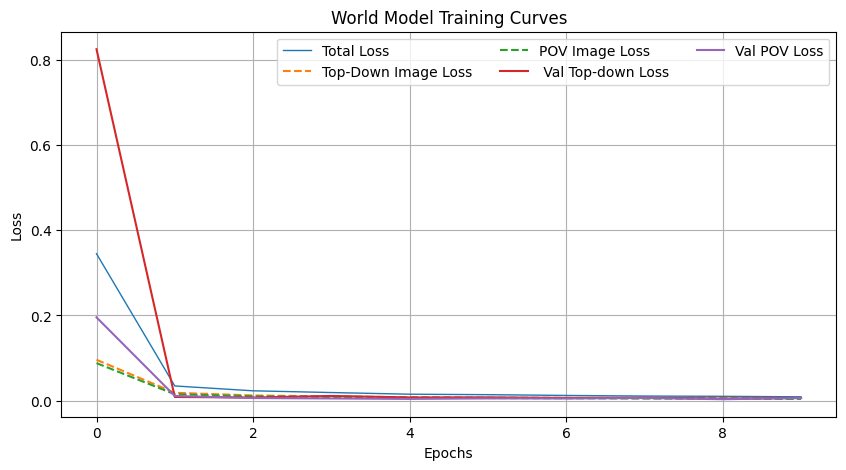

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Total Loss', linewidth=1)
plt.plot(img_losses, label='Top-Down Image Loss', linestyle='--')
plt.plot(pov_losses, label='POV Image Loss', linestyle='--')
plt.plot(val_img_losses, label=' Val Top-down Loss', linestyle='-')
plt.plot(val_pov_losses, label='Val POV Loss', linestyle='-')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('World Model Training Curves')
plt.legend(ncols=3)
plt.grid(True)
plt.show()

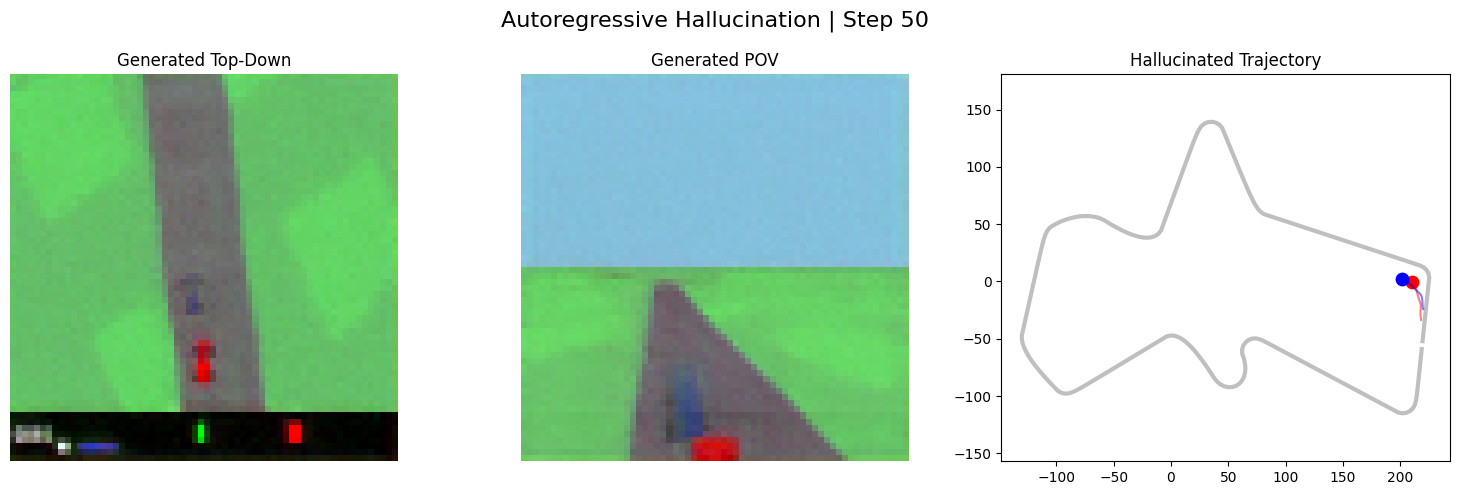

In [13]:
@torch.no_grad()
def autoregressive_rollout(model, buffer, device, rollout_steps=50, seq_len=8):
    model.eval()
    
    # 1. Grab a continuous chunk of data to get the ground truth ACTIONS and MAP
    # We need rollout_steps + seq_len steps of data to get the true actions the agent took.
    # Note: You may need a modified buffer function to get a guaranteed continuous 60-step chunk
    (i_full, pov_full, p_full, a_full, 
     g_map, mask_full, 
     b_p_full, b_a_full, 
     _, _, _, _) = buffer.sample_sequence(batch_size=1, seq_len=rollout_steps + seq_len, device=device)

    # 2. Extract the static global map
    track_padded = g_map[0, 0].cpu().numpy()
    track_mask = mask_full[0, 0].cpu().numpy()
    track = track_padded[track_mask]

    # 3. Initialize the Sliding Windows with the "Burn-in" sequence (first 8 real frames)
    curr_img_seq = i_full[:, :seq_len].clone()
    curr_pov_seq = pov_full[:, :seq_len].clone()
    curr_p_seq = p_full[:, :seq_len].clone()
    curr_b_p_seq = b_p_full[:, :seq_len].clone()
    
    # Storage for visualizations
    generated_td_imgs = []
    generated_pov_imgs = []
    generated_red_poses = [curr_p_seq[0, -1].cpu().numpy()]
    generated_blue_poses = [curr_b_p_seq[0, -1].cpu().numpy()]

    print(f"Starting {rollout_steps}-step Autoregressive Rollout...")

    # 4. The Autoregressive Loop
    for step in range(rollout_steps):
        # We feed the real actions for the CURRENT step being predicted
        curr_a_seq = a_full[:, step : step + seq_len]
        curr_b_a_seq = b_a_full[:, step : step + seq_len]
        
        # Run generation
        pred_img, pred_pov, pr_red_d, pr_blue_d = model.sample(
            curr_img_seq, curr_pov_seq, curr_p_seq, curr_a_seq, 
            curr_b_p_seq, curr_b_a_seq, g_map[:, 0:1], mask_full[:, 0:1]
        )

        # Calculate new absolute poses
        new_red_pose = curr_p_seq[:, -1] + pr_red_d
        new_blue_pose = curr_b_p_seq[:, -1] + pr_blue_d

        # Store outputs for plotting
        generated_td_imgs.append(pred_img)
        generated_pov_imgs.append(pred_pov)
        generated_red_poses.append(new_red_pose[0].cpu().numpy())
        generated_blue_poses.append(new_blue_pose[0].cpu().numpy())

        # ==========================================
        # SLIDING WINDOW UPDATE
        # ==========================================
        # Drop the oldest frame (index 0) and append the newly hallucinated frame/pose
        curr_img_seq = torch.cat([curr_img_seq[:, 1:], pred_img.unsqueeze(1)], dim=1)
        curr_pov_seq = torch.cat([curr_pov_seq[:, 1:], pred_pov.unsqueeze(1)], dim=1)
        curr_p_seq = torch.cat([curr_p_seq[:, 1:], new_red_pose.unsqueeze(1)], dim=1)
        curr_b_p_seq = torch.cat([curr_b_p_seq[:, 1:], new_blue_pose.unsqueeze(1)], dim=1)

        print(f"Generated step {step + 1}/{rollout_steps}")

    return generated_td_imgs, generated_pov_imgs, generated_red_poses, generated_blue_poses, track


# --- RUN THE ROLLOUT AND ANIMATE ---
# Note: Ensure your buffer has sequences long enough to supply the actions (e.g., 50+8 steps)
gen_td, gen_pov, gen_red_p, gen_blue_p, track_map = autoregressive_rollout(model, buffer, device, rollout_steps=50)

# Animate the hallucinated future
for t in range(len(gen_td)):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Autoregressive Hallucination | Step {t+1}", fontsize=16)

    # Convert tensors to numpy images
    img_td = ((gen_td[t].squeeze().cpu().numpy().transpose(1, 2, 0) + 1.0) / 2.0 * 255).clip(0, 255).astype(np.uint8)
    img_pov = ((gen_pov[t].squeeze().cpu().numpy().transpose(1, 2, 0) + 1.0) / 2.0 * 255).clip(0, 255).astype(np.uint8)

    axes[0].imshow(img_td)
    axes[0].set_title("Generated Top-Down")
    axes[0].axis('off')

    axes[1].imshow(img_pov)
    axes[1].set_title("Generated POV")
    axes[1].axis('off')

    axes[2].set_title("Hallucinated Trajectory")
    axes[2].plot(track_map[:, 0], track_map[:, 1], c='gray', linewidth=3, alpha=0.5)
    
    # Plot history of generated path up to step t
    red_history = np.array(gen_red_p[:t+2])
    blue_history = np.array(gen_blue_p[:t+2])
    axes[2].plot(red_history[:, 0], red_history[:, 1], c='red', alpha=0.5, label='Red Path')
    axes[2].plot(blue_history[:, 0], blue_history[:, 1], c='blue', alpha=0.5, label='Blue Path')
    
    # Plot current position
    axes[2].scatter(red_history[-1, 0], red_history[-1, 1], c='red', s=80)
    axes[2].scatter(blue_history[-1, 0], blue_history[-1, 1], c='blue', s=80)
    axes[2].set_aspect('equal', adjustable='datalim')
    if t == 0: axes[2].legend()

    plt.tight_layout()
    plt.show()